In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import autoslo.utils.paths as pu
import autoslo.utils.colors as pc
import matplotlib.dates as mdates



df = pd.read_parquet(pu.get_redset_raw_data(cluster_id=157))

mask = (
    (~df["was_cached"])
    & (df["query_type"].str.lower() == "select")
    & (df["feature_fingerprint"].notna())
)
df = df[mask]

df.shape

(123103, 24)

In [71]:
df['arrival_timestamp'].min(), df['arrival_timestamp'].max()

(Timestamp('2024-03-01 00:07:53.848406'),
 Timestamp('2024-05-29 23:39:23.597196'))

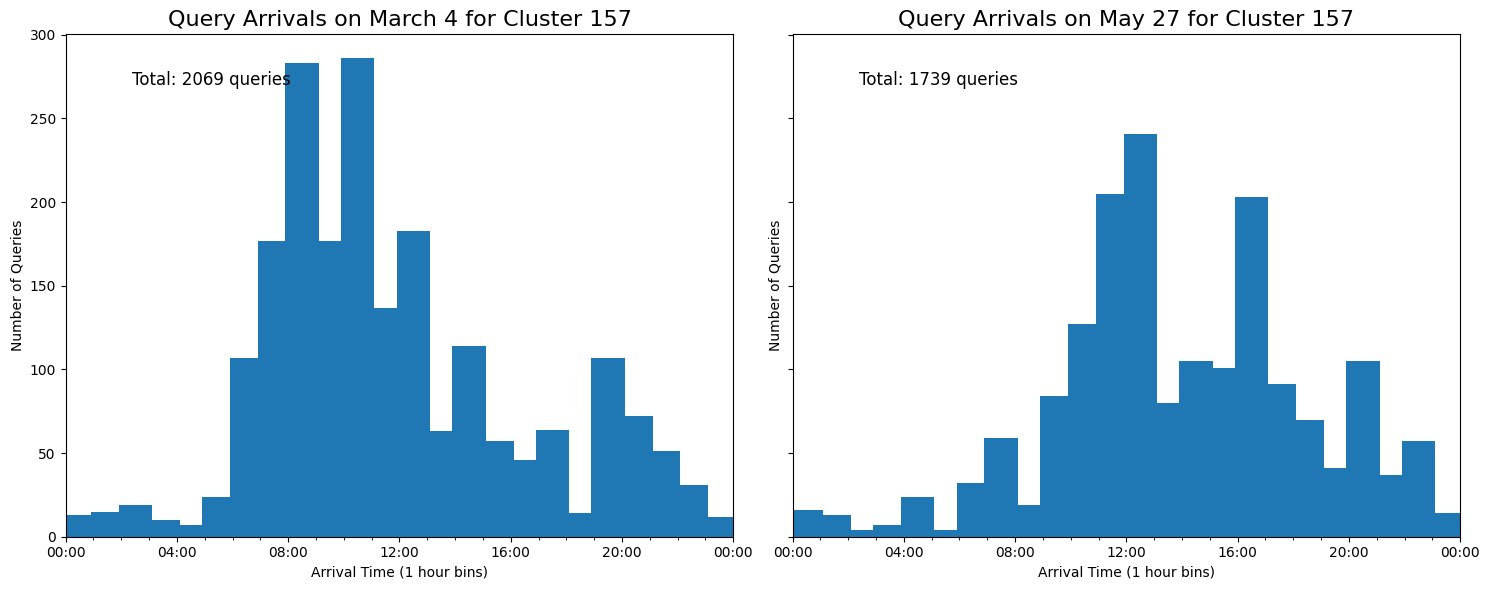

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df["arrival_1h"] = df["arrival_timestamp"].dt.floor("1h")
cluster_id = 157

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

first_day = pd.to_datetime("2024-03-04").date()
last_day  = pd.to_datetime("2024-05-27").date()

first_day_df = df[df["arrival_timestamp"].dt.date == first_day]
last_day_df  = df[df["arrival_timestamp"].dt.date == last_day]

def plot_day_counts(day_df, ax, title):
    # Aggregate counts per 1-hour bin (datetime index!)
    counts = (
        day_df.groupby("arrival_1h")
              .size()
              .sort_index()
    )

    # Fill missing 1-hour bins so spacing is uniform
    full_idx = pd.date_range(counts.index.min().floor("D"),
                             counts.index.max().ceil("D"),
                             freq="60min")
    counts = counts.reindex(full_idx, fill_value=0)

    ax.bar([x + pd.Timedelta(minutes=30) for x in counts.index], counts.values, width=0.05)  # or ax.bar(..., width=...) if you want bars
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Arrival Time (1 hour bins)")
    ax.set_ylabel("Number of Queries")

    # Now locators/formatters work because axis is datetime
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
    ax.tick_params(axis="x")

    ax.text(0.1, 0.9, f"Total: {counts.sum()} queries", transform=ax.transAxes, ha="left", fontsize=12)

    ax.set_xlim(counts.index.min(), counts.index.max())

plot_day_counts(first_day_df, ax[0], f"Query Arrivals on March 4 for Cluster {cluster_id}")
plot_day_counts(last_day_df,  ax[1], f"Query Arrivals on May 27 for Cluster {cluster_id}")

plt.tight_layout()
plt.show()

In [82]:
num_queries = 2069
num_hours = 4
print(f"If we execute {num_queries} queries in {num_hours} hours, that's one every {num_hours*3600/num_queries:.1f} seconds on average.")

If we execute 2069 queries in 4 hours, that's one every 7.0 seconds on average.
